In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [31]:
df = pd.read_csv("/content/Titanic-Dataset (2).csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
# Dataset information
df.info()

# Statistical summary
display(df.describe())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicates:", df.duplicated().sum())

# Target distribution
print("\nSurvival Count:")
print(df['Survived'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicates: 0

Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64


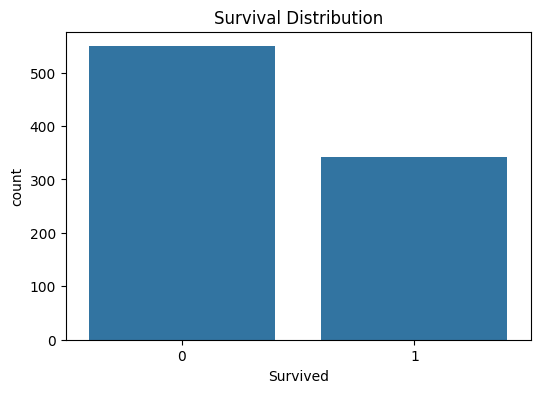

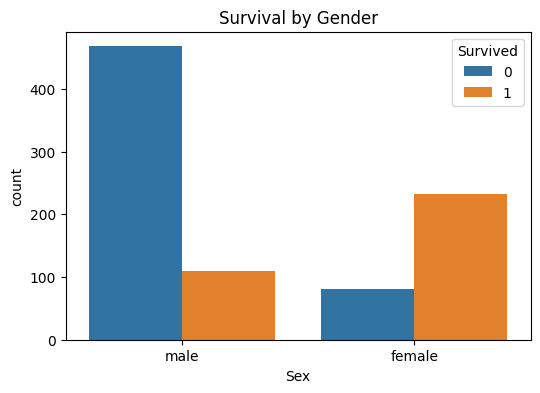

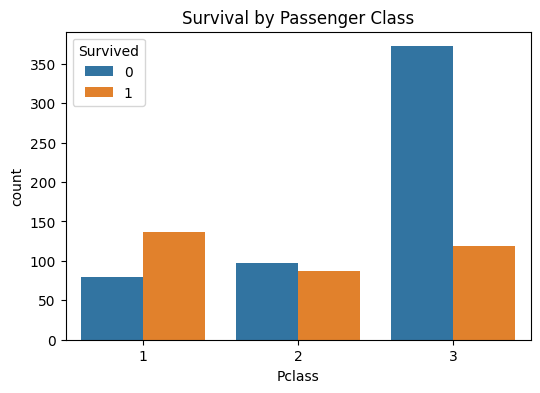

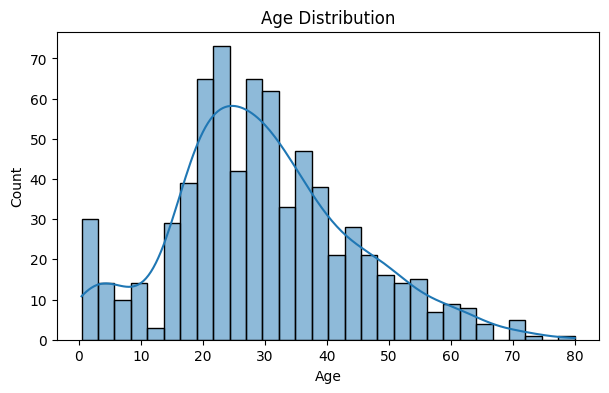

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived')
plt.title("Survival Distribution")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival by Gender")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title("Survival by Passenger Class")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

In [34]:
# Input features
X = df.drop(columns=[
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin',
    'Survived'
])

# Target variable
y = df['Survived']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target:
Survived


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (712, 7)
Testing Features: (179, 7)
Training Target: (712,)
Testing Target: (179,)


In [36]:
# Numerical columns
num_cols = [
    'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'
]

# Categorical columns
cat_cols = [
    'Sex', 'Embarked'
]

# Numerical preprocessing
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244
1,Decision Tree,0.8156,0.7903,0.7101,0.7481
2,Random Forest,0.8156,0.8000,0.6957,0.7442


In [38]:
# Create Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Parameter grid
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# Grid Search
grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 50}

Best Cross-Validation Accuracy:
0.8259036737909978


In [39]:
# Best model from GridSearchCV
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877
Precision: 0.8070175438596491
Recall: 0.6666666666666666
F1 Score: 0.7301587301587301

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



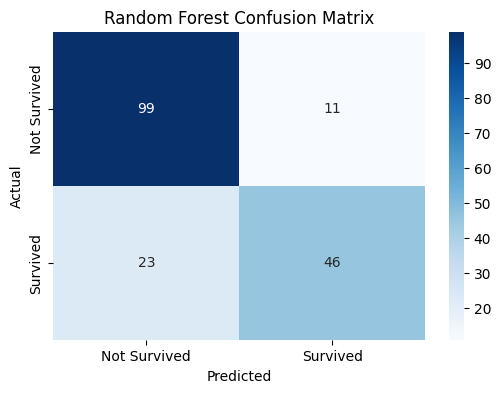

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244
1,Decision Tree,0.8156,0.7903,0.7101,0.7481
2,Random Forest,0.8156,0.8000,0.6957,0.7442
3,Tuned Random Forest,0.8101,0.8070,0.6667,0.7302


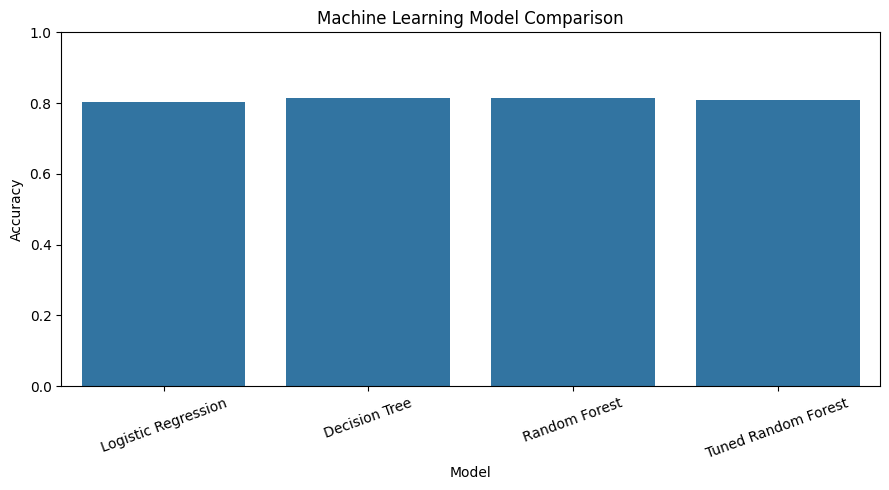

In [41]:
# Add tuned Random Forest result
tuned_result = pd.DataFrame([{
    'Model': 'Tuned Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}])

comparison_df = pd.concat(
    [results_df, tuned_result],
    ignore_index=True
)

display(comparison_df.round(4))

# Visual comparison
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Accuracy'
)

plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.title("Machine Learning Model Comparison")
plt.tight_layout()
plt.show()

In [42]:
new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': ['male'],
    'Age': [25],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': ['S']
})

prediction = best_model.predict(new_passenger)

probability = best_model.predict_proba(new_passenger)[0][1]

if prediction[0] == 1:
    print("Prediction: Survived")
else:
    print("Prediction: Not Survived")

print(f"Survival Probability: {probability:.2%}")

Prediction: Not Survived
Survival Probability: 4.65%


In [43]:
import joblib

joblib.dump(best_model, "titanic_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [44]:
loaded_model = joblib.load("titanic_random_forest.pkl")

prediction = loaded_model.predict(new_passenger)

print("Prediction:", prediction[0])

Prediction: 0
